# Review Analysis Notebook

This notebook analyzes criterion-based review JSON files generated by your analytical reviewer prompt.

It focuses on descriptive insights before consistency checking:

- dimension score distributions
- confidence distribution
- criterion-level verdict and score patterns
- penalty activation
- partial-score usage
- weakest and strongest criteria
- differences across generator models, reviewer models, and topics

Edit only the path configuration cell below.

In [28]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

REVIEW_DIRS = [
    Path("review_outputs/qwen3_5_9b_reviewer/qwen3_8b_cluster_v4"),
]

# Optional: restrict file pattern if needed
FILE_PATTERN = "*.analysis.json"


## 1. Load review JSON files

In [4]:
def load_review_files(review_dirs, pattern="*.analysis.json"):
    records = []
    criteria_records = []

    for review_dir in review_dirs:
        paths = sorted(review_dir.rglob(pattern))
        print(f"{review_dir}: {len(paths)} files")

        for path in paths:
            with path.open("r", encoding="utf-8") as f:
                review = json.load(f)

            dim = review.get("dimension_scores", {})
            base = {
                "file": str(path),
                "paper_id": review.get("paper_id"),
                "generator_model": review.get("generator_model"),
                "topic": review.get("topic"),
                "selected_title": review.get("selected_title"),
                "model_reviewing": review.get("model_reviewing"),
                "summary": review.get("summary"),
                "clarity": dim.get("clarity"),
                "soundness": dim.get("soundness"),
                "novelty": dim.get("novelty"),
                "empirical_quality": dim.get("empirical_quality"),
                "confidence": review.get("confidence"),
                "num_strengths": len(review.get("strengths", [])),
                "num_weaknesses": len(review.get("weaknesses", [])),
            }
            records.append(base)

            for c in review.get("criteria_evaluation", []):
                criteria_records.append({**{k: base[k] for k in ["file", "paper_id", "generator_model", "topic", "selected_title", "model_reviewing"]},
                    "criterion_name": c.get("name"),
                    "criterion_dimension": c.get("dimension"),
                    "verdict": c.get("verdict"),
                    "criterion_score": c.get("score"),
                    "weight": c.get("weight"),
                    "weighted_contribution": c.get("score", 0) * c.get("weight", 0),
                    "evidence": c.get("evidence"),
                    "explanation": c.get("explanation"),
                })

    return pd.DataFrame(records), pd.DataFrame(criteria_records)

df_reviews, df_criteria = load_review_files(REVIEW_DIRS, FILE_PATTERN)

print("reviews:", df_reviews.shape)
print("criteria:", df_criteria.shape)

df_reviews.head()


review_outputs/qwen3_5_9b_reviewer/qwen3_8b_cluster_v4: 130 files
reviews: (130, 14)
criteria: (2470, 14)


,file,paper_id,generator_model,topic,selected_title,model_reviewing,summary,clarity,soundness,novelty,empirical_quality,confidence,num_strengths,num_weaknesses
0,review_outputs/qwen3_5_9b_reviewer/qwen3_8b_cluster_v4/idea_001_01.analysis.json,idea_001_01,qwen3:8b,representation learning for sequential decision making,Unsupervised State Representation Learning for Enhanced Decision-Making in Partially Observable Environments,qwen3.5:9b,The paper proposes an unsupervised method for learning state representations in partially observable environments using predictive coding principles. The me...,3,2,2,2,3,5,5
1,review_outputs/qwen3_5_9b_reviewer/qwen3_8b_cluster_v4/idea_001_02.analysis.json,idea_001_02,qwen3:8b,representation learning for sequential decision making,Improving Planning Efficiency via Unsupervised State Embedding in Reinforcement Learning,qwen3.5:9b,The paper proposes an unsupervised state embedding framework to improve planning efficiency in partially observable reinforcement learning environments. It ...,3,2,2,2,3,2,4
2,review_outputs/qwen3_5_9b_reviewer/qwen3_8b_cluster_v4/idea_001_03.analysis.json,idea_001_03,qwen3:8b,representation learning for sequential decision making,Autonomous Discovery of Rich Representations for Sequential Decision Making under Uncertainty,qwen3.5:9b,"The paper proposes a unified, unsupervised framework for learning task-specific state representations in partially observable environments. It jointly optim...",3,2,3,2,3,5,5
3,review_outputs/qwen3_5_9b_reviewer/qwen3_8b_cluster_v4/idea_001_04.analysis.json,idea_001_04,qwen3:8b,representation learning for sequential decision making,Leveraging Unsupervised Learning to Enhance Exploration in Partially Observable Markov Decision Processes,qwen3.5:9b,The paper proposes an unsupervised representation learning framework using autoencoders to enhance exploration in POMDPs. The method involves training an au...,3,2,2,2,2,2,5
4,review_outputs/qwen3_5_9b_reviewer/qwen3_8b_cluster_v4/idea_001_05.analysis.json,idea_001_05,qwen3:8b,representation learning for sequential decision making,Adaptive Unsupervised Feature Learning for Enhanced Policy Learning in Complex Environments,qwen3.5:9b,"The paper proposes Adaptive Unsupervised Feature Learning (AUFL), a framework for representation learning in reinforcement learning (RL) that avoids explici...",3,2,2,2,2,2,5


## 2. Basic dataset overview

In [5]:
overview = pd.DataFrame({
    "num_reviews": [len(df_reviews)],
    "num_unique_papers": [df_reviews["paper_id"].nunique()],
    "num_topics": [df_reviews["topic"].nunique()],
    "num_generator_models": [df_reviews["generator_model"].nunique()],
    "num_reviewer_models": [df_reviews["model_reviewing"].nunique()],
})
overview


,num_reviews,num_unique_papers,num_topics,num_generator_models,num_reviewer_models
0,130,130,26,1,1


## 3. Dimension score distributions

- Clarity
- Soundness
- Novelty
- Empirical quality

    and 

- Confidence

In [7]:
score_cols = ["clarity", "soundness", "novelty", "empirical_quality"]

df_reviews[score_cols + ["confidence"]].describe()


,clarity,soundness,novelty,empirical_quality,confidence
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,3.292308,2.107692,2.330769,2.146154,2.800000
std,0.473256,0.417563,0.488447,0.598597,0.697726
min,2.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,2.000000,2.000000,2.000000
50%,3.000000,2.000000,2.000000,2.000000,3.000000
75%,4.000000,2.000000,3.000000,2.000000,3.000000
max,4.000000,3.000000,3.000000,4.000000,4.000000


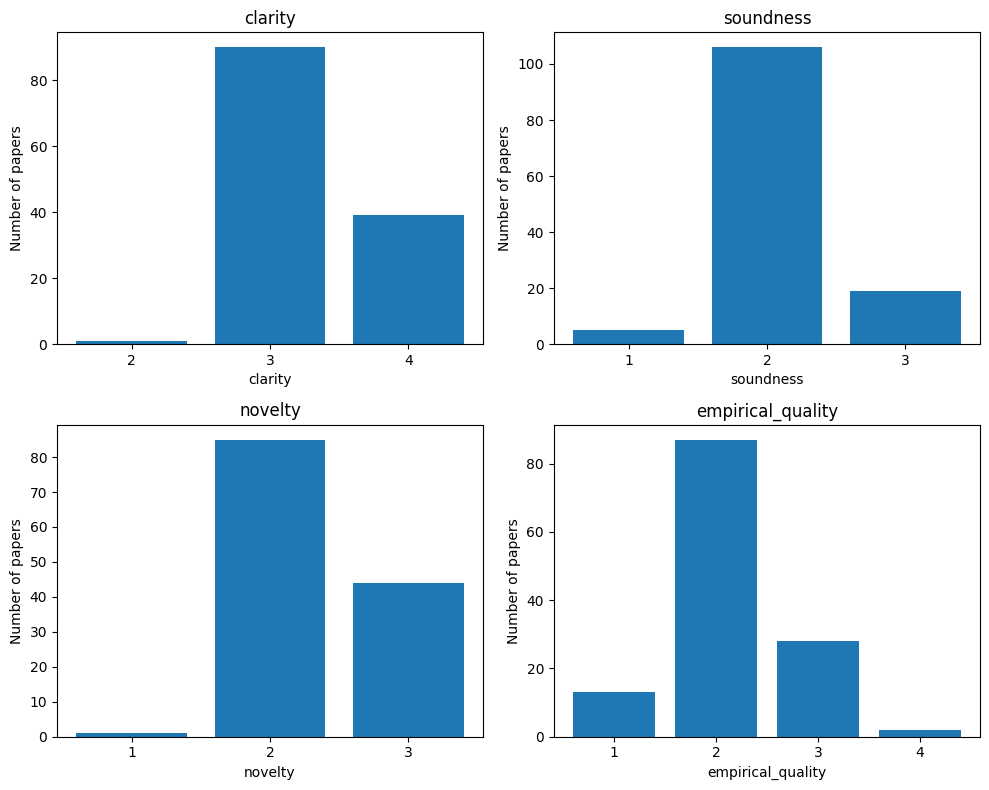

In [29]:


n_cols = 2  
n_rows = math.ceil(len(score_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  

for i, col in enumerate(score_cols):
    counts = df_reviews[col].value_counts().sort_index()

    axes[i].bar(counts.index.astype(str), counts.values)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of papers")
    axes[i].set_title(f"{col}")

plt.tight_layout()
plt.show()

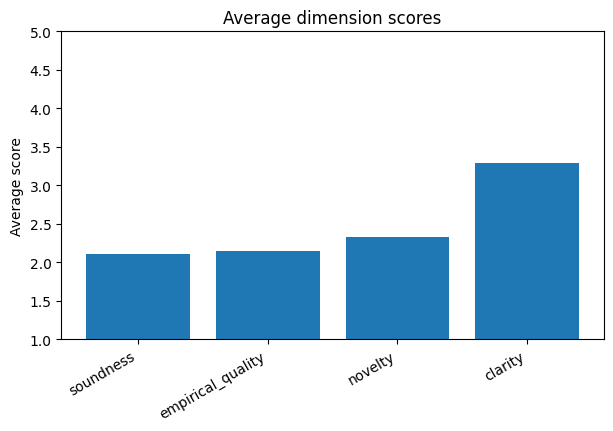

soundness            2.107692
empirical_quality    2.146154
novelty              2.330769
clarity              3.292308
dtype: float64

In [9]:
mean_scores = df_reviews[score_cols].mean().sort_values()
plt.figure(figsize=(7, 4))
plt.bar(mean_scores.index, mean_scores.values)
plt.ylabel("Average score")
plt.title("Average dimension scores")
plt.ylim(1, 5)
plt.xticks(rotation=30, ha="right")
plt.show()
mean_scores


## 4. Confidence distribution

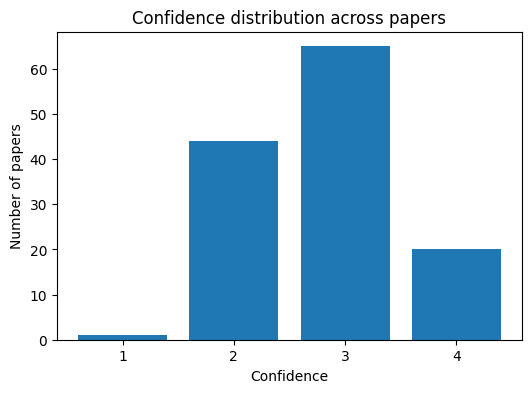

,count
confidence,
1,1
2,44
3,65
4,20


In [10]:
counts = df_reviews["confidence"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Confidence")
plt.ylabel("Number of papers")
plt.title("Confidence distribution across papers")
plt.show()

counts.to_frame("count")


## 5. Criterion-level verdict distribution

In [31]:
verdict_order = ["not_satisfied", "partially_satisfied", "satisfied"]

verdict_counts = (df_criteria.groupby(["criterion_name", "verdict"]).size().unstack(fill_value=0).reindex(columns=verdict_order, fill_value=0))

verdict_props = verdict_counts.div(verdict_counts.sum(axis=1), axis=0)
verdict_props.head(20)


verdict,not_satisfied,partially_satisfied,satisfied
criterion_name,,,
assumptions_explicit_and_reasonable,0.130769,0.853846,0.015385
baselines_clearly_named,0.015385,0.607692,0.376923
comparison_to_prior_work,0.030769,0.946154,0.023077
contribution_clearly_identified,0.000000,0.415385,0.584615
datasets_and_setup_specified,0.138462,0.846154,0.015385
evaluation_metrics_defined,0.046154,0.500000,0.453846
experiments_support_claims,0.392308,0.576923,0.030769
generic_or_boilerplate_limitations,0.184615,0.684615,0.130769
method_clearly_explained,0.000000,0.776923,0.223077


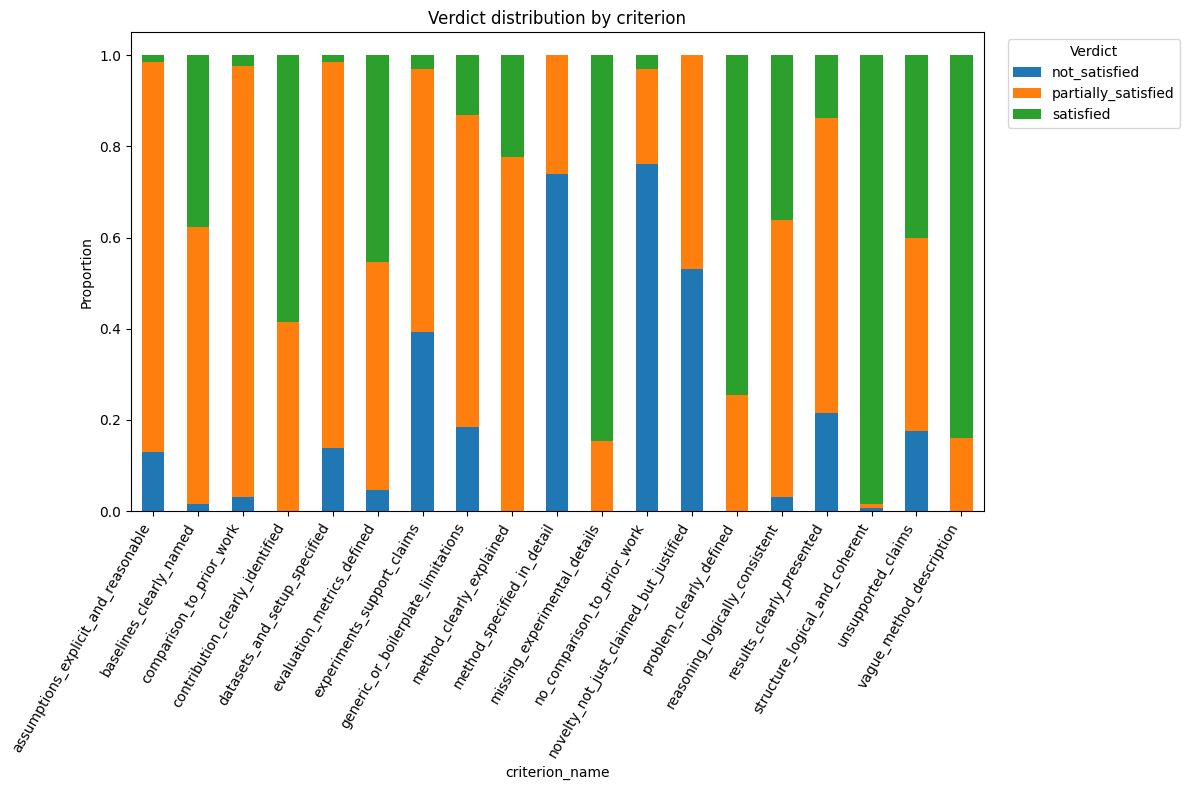

In [12]:
verdict_props.plot(kind="bar", stacked=True, figsize=(12, 8))
plt.ylabel("Proportion")
plt.title("Verdict distribution by criterion")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Verdict", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Positive criteria vs penalty criteria

In [ ]:
df_criteria["is_penalty"] = df_criteria["criterion_dimension"].eq("penalty")

summary_by_type = (df_criteria.groupby("is_penalty")
    .agg(
        n=("criterion_score", "size"),
        mean_score=("criterion_score", "mean"),
        partial_rate=("criterion_score", lambda s: (s == 0.5).mean()),
        zero_rate=("criterion_score", lambda s: (s == 0.0).mean()),
        one_rate=("criterion_score", lambda s: (s == 1.0).mean()),
    ).rename(index={False: "positive_criteria", True: "penalty_criteria"})
)
summary_by_type


,n,mean_score,partial_rate,zero_rate,one_rate
is_penalty,,,,,
positive_criteria,1820,0.559890,0.554945,0.162637,0.282418
penalty_criteria,650,0.612308,0.326154,0.224615,0.449231


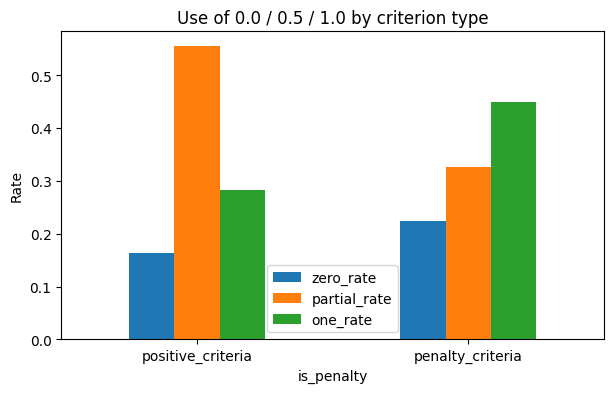

In [14]:
plot_df = summary_by_type[["zero_rate", "partial_rate", "one_rate"]]
plot_df.plot(kind="bar", figsize=(7, 4))
plt.ylabel("Rate")
plt.title("Use of 0.0 / 0.5 / 1.0 by criterion type")
plt.xticks(rotation=0)
plt.show()


## 7. Penalty activation analysis

For penalties, `score > 0` means the flaw was activated at least partially.

In [15]:
df_penalties = df_criteria[df_criteria["is_penalty"]].copy()

penalty_activation = (
    df_penalties.groupby("criterion_name")
    .agg(
        activation_rate=("criterion_score", lambda s: (s > 0).mean()),
        full_penalty_rate=("criterion_score", lambda s: (s == 1.0).mean()),
        partial_penalty_rate=("criterion_score", lambda s: (s == 0.5).mean()),
        mean_penalty_score=("criterion_score", "mean"),
        mean_weighted_penalty=("weighted_contribution", "mean"),
    )
    .sort_values("activation_rate", ascending=False)
)
penalty_activation


,activation_rate,full_penalty_rate,partial_penalty_rate,mean_penalty_score,mean_weighted_penalty
criterion_name,,,,,
missing_experimental_details,1.000000,0.846154,0.153846,0.923077,-4.615385
vague_method_description,1.000000,0.838462,0.161538,0.919231,-3.676923
unsupported_claims,0.823077,0.400000,0.423077,0.611538,-2.446154
generic_or_boilerplate_limitations,0.815385,0.130769,0.684615,0.473077,-0.946154
no_comparison_to_prior_work,0.238462,0.030769,0.207692,0.134615,-0.538462


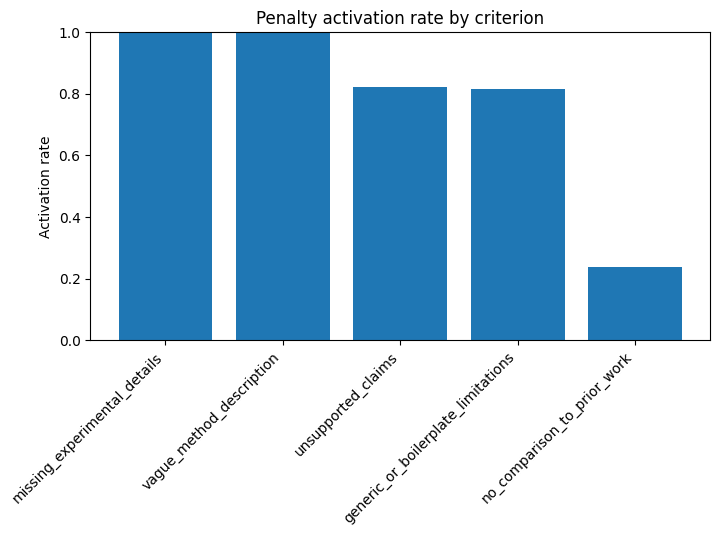

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(penalty_activation.index, penalty_activation["activation_rate"])
plt.ylabel("Activation rate")
plt.title("Penalty activation rate by criterion")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()


## 8. Weakest and strongest criteria

For positive criteria, lower mean score means the criterion is often missing or only partially satisfied.
For penalty criteria, higher mean score means the flaw is more often present.

In [17]:
positive_criteria = df_criteria[~df_criteria["is_penalty"]]

criterion_strength = (
    positive_criteria.groupby(["criterion_dimension", "criterion_name"])
    .agg(
        mean_score=("criterion_score", "mean"),
        partial_rate=("criterion_score", lambda s: (s == 0.5).mean()),
        missing_rate=("criterion_score", lambda s: (s == 0.0).mean()),
        satisfied_rate=("criterion_score", lambda s: (s == 1.0).mean()),
    )
    .sort_values("mean_score")
)
criterion_strength


mean_score  \
criterion_dimension criterion_name                                       
soundness           method_specified_in_detail                0.130769   
novelty             novelty_not_just_claimed_but_justified    0.234615   
empirical_quality   experiments_support_claims                0.319231   
                    datasets_and_setup_specified              0.438462   
soundness           assumptions_explicit_and_reasonable       0.442308   
empirical_quality   results_clearly_presented                 0.461538   
novelty             comparison_to_prior_work                  0.496154   
clarity             method_clearly_explained                  0.611538   
soundness           reasoning_logically_consistent            0.665385   
empirical_quality   baselines_clearly_named                   0.680769   
                    evaluation_metrics_defined                0.703846   
novelty             contribution_clearly_identified           0.792308   
clarity             problem_clearly_defined                   0.873077   
                    structure_logical_and_coherent            0.988462   

                                                            partial_rate  \
criterion_dimension criterion_name                                         
soundness           method_specified_in_detail                  0.261538   
novelty             novelty_not_just_claimed_but_justified      0.469231   
empirical_quality   experiments_support_claims                  0.576923   
                    datasets_and_setup_specified                0.846154   
soundness           assumptions_explicit_and_reasonable         0.853846   
empirical_quality   results_clearly_presented                   0.646154   
novelty             comparison_to_prior_work                    0.946154   
clarity             method_clearly_explained                    0.776923   
soundness           reasoning_logically_consistent              0.607692   
empirical_quality   baselines_clearly_named                     0.607692   
                    evaluation_metrics_defined                  0.500000   
novelty             contribution_clearly_identified             0.415385   
clarity             problem_clearly_defined                     0.253846   
                    structure_logical_and_coherent              0.007692   

                                                            missing_rate  \
criterion_dimension criterion_name                                         
soundness           method_specified_in_detail                  0.738462   
novelty             novelty_not_just_claimed_but_justified      0.530769   
empirical_quality   experiments_support_claims                  0.392308   
                    datasets_and_setup_specified                0.138462   
soundness           assumptions_explicit_and_reasonable         0.130769   
empirical_quality   results_clearly_presented                   0.215385   
novelty             comparison_to_prior_work                    0.030769   
clarity             method_clearly_explained                    0.000000   
soundness           reasoning_logically_consistent              0.030769   
empirical_quality   baselines_clearly_named                     0.015385   
                    evaluation_metrics_defined                  0.046154   
novelty             contribution_clearly_identified             0.000000   
clarity             problem_clearly_defined                     0.000000   
                    structure_logical_and_coherent              0.007692   

                                                            satisfied_rate  
criterion_dimension criterion_name                                          
soundness           method_specified_in_detail                    0.000000  
novelty             novelty_not_just_claimed_but_justified        0.000000  
empirical_quality   experiments_support_claims                    0.030769  
                    datasets_and_setup_specified        

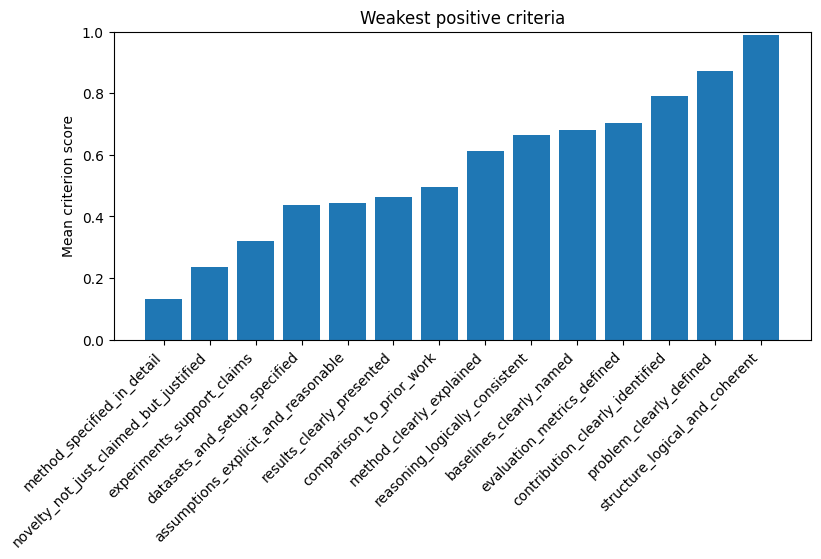

,criterion_dimension,criterion_name,mean_score,partial_rate,missing_rate,satisfied_rate
0,soundness,method_specified_in_detail,0.130769,0.261538,0.738462,0.000000
1,novelty,novelty_not_just_claimed_but_justified,0.234615,0.469231,0.530769,0.000000
2,empirical_quality,experiments_support_claims,0.319231,0.576923,0.392308,0.030769
3,empirical_quality,datasets_and_setup_specified,0.438462,0.846154,0.138462,0.015385
4,soundness,assumptions_explicit_and_reasonable,0.442308,0.853846,0.130769,0.015385
5,empirical_quality,results_clearly_presented,0.461538,0.646154,0.215385,0.138462
6,novelty,comparison_to_prior_work,0.496154,0.946154,0.030769,0.023077
7,clarity,method_clearly_explained,0.611538,0.776923,0.000000,0.223077
8,soundness,reasoning_logically_consistent,0.665385,0.607692,0.030769,0.361538
9,empirical_quality,baselines_clearly_named,0.680769,0.607692,0.015385,0.376923


In [32]:
weakest = criterion_strength.head(15).reset_index()
plt.figure(figsize=(9, 4))
plt.bar(weakest["criterion_name"], weakest["mean_score"])
plt.ylabel("Mean criterion score")
plt.title("Weakest positive criteria")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()
weakest


## 9. Weighted contribution analysis

This shows which criteria contribute most positively or negatively to the overall assessment.

In [19]:
weighted_summary = (
    df_criteria.groupby(["criterion_dimension", "criterion_name"])
    .agg(
        mean_score=("criterion_score", "mean"),
        weight=("weight", "first"),
        mean_weighted_contribution=("weighted_contribution", "mean"),
    )
    .sort_values("mean_weighted_contribution")
)
weighted_summary


mean_score  \
criterion_dimension criterion_name                                       
penalty             missing_experimental_details              0.923077   
                    vague_method_description                  0.919231   
                    unsupported_claims                        0.611538   
                    generic_or_boilerplate_limitations        0.473077   
                    no_comparison_to_prior_work               0.134615   
soundness           method_specified_in_detail                0.130769   
novelty             novelty_not_just_claimed_but_justified    0.234615   
soundness           assumptions_explicit_and_reasonable       0.442308   
empirical_quality   experiments_support_claims                0.319231   
                    results_clearly_presented                 0.461538   
                    datasets_and_setup_specified              0.438462   
clarity             method_clearly_explained                  0.611538   
                    structure_logical_and_coherent            0.988462   
novelty             comparison_to_prior_work                  0.496154   
soundness           reasoning_logically_consistent            0.665385   
empirical_quality   evaluation_metrics_defined                0.703846   
novelty             contribution_clearly_identified           0.792308   
clarity             problem_clearly_defined                   0.873077   
empirical_quality   baselines_clearly_named                   0.680769   

                                                            weight  \
criterion_dimension criterion_name                                   
penalty             missing_experimental_details                -5   
                    vague_method_description                    -4   
                    unsupported_claims                          -4   
                    generic_or_boilerplate_limitations          -2   
                    no_comparison_to_prior_work                 -4   
soundness           method_specified_in_detail                   4   
novelty             novelty_not_just_claimed_but_justified       3   
soundness           assumptions_explicit_and_reasonable          2   
empirical_quality   experiments_support_claims                   4   
                    results_clearly_presented                    3   
                    datasets_and_setup_specified                 4   
clarity             method_clearly_explained                     3   
                    structure_logical_and_coherent               2   
novelty             comparison_to_prior_work                     4   
soundness           reasoning_logically_consistent               3   
empirical_quality   evaluation_metrics_defined                   3   
novelty             contribution_clearly_identified              3   
clarity             problem_clearly_defined                      3   
empirical_quality   baselines_clearly_named                      4   

                                                            mean_weighted_contribution  
criterion_dimension criterion_name                                                      
penalty             missing_experimental_details                             -4.615385  
                    vague_method_description                                 -3.676923  
                    unsupported_claims                                       -2.446154  
                    generic_or_boilerplate_limitations                       -0.946154  
                    no_comparison_to_prior_work                              -0.538462  
soundness           method_specified_in_detail                                0.523077  
novelty             novelty_not_just_claimed_but_justified                    0.703846  
soundness           assumptions_explicit_and_reasonable                       0.884615  
empirical_quality   experiments_support_claims                                1.276923  
                    results_clearly_presented          

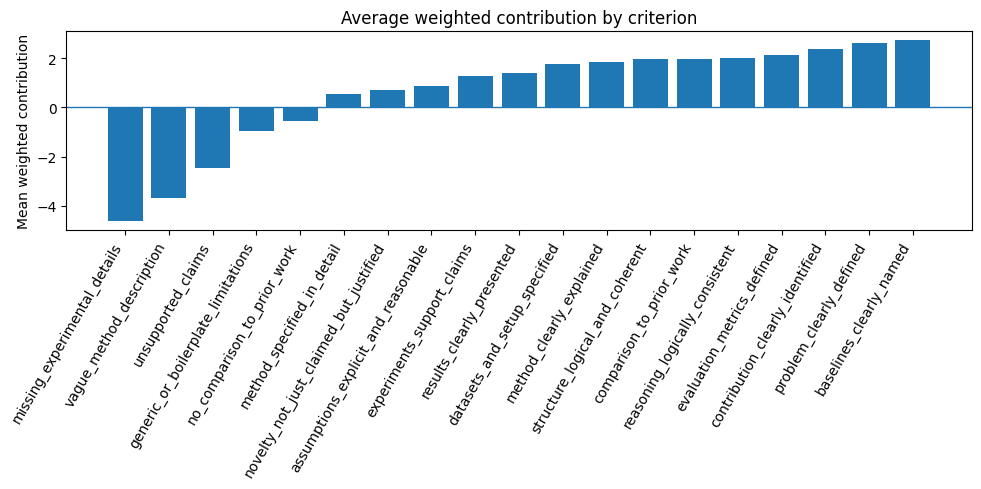

In [20]:
tmp = weighted_summary.reset_index()
plt.figure(figsize=(10, 5))
plt.bar(tmp["criterion_name"], tmp["mean_weighted_contribution"])
plt.axhline(0, linewidth=1)
plt.ylabel("Mean weighted contribution")
plt.title("Average weighted contribution by criterion")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


## 10. Topic-level insights

In [21]:
topic_scores = (
    df_reviews.groupby("topic")
    .agg(
        n=("paper_id", "count"),
        clarity=("clarity", "mean"),
        soundness=("soundness", "mean"),
        novelty=("novelty", "mean"),
        empirical_quality=("empirical_quality", "mean"),
        confidence=("confidence", "mean"),
    )
    .sort_values("empirical_quality")
)
topic_scores


,n,clarity,soundness,novelty,empirical_quality,confidence
topic,,,,,,
robustness and adversarial stability of representations,5,3.2,1.8,2.4,1.6,2.4
metric learning for vision,5,3.0,1.8,1.8,1.6,2.4
world models for decision making,5,3.2,2.0,2.4,1.8,2.8
transfer learning and domain adaptation for representations,5,3.4,2.2,2.6,1.8,3.2
representation learning for time-series data,5,3.2,2.0,2.2,1.8,3.2
generalization in overparameterized neural networks,5,3.0,2.0,2.0,1.8,2.4
representation learning for sequential decision making,5,3.0,2.0,2.2,2.0,2.6
representation learning for robotics,5,3.2,2.0,2.0,2.0,2.6
model-based reinforcement learning with learned representations,5,3.4,2.2,2.6,2.0,2.6


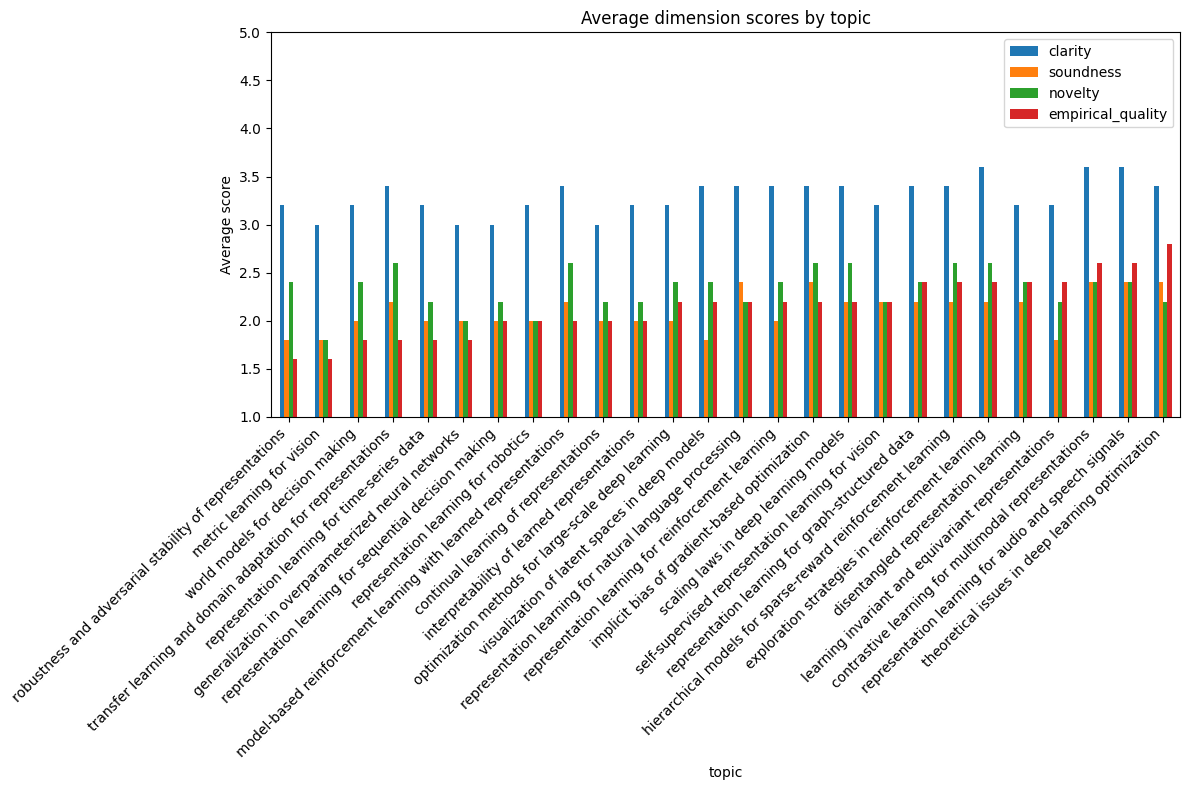

In [33]:
if df_reviews["topic"].nunique() > 1:
    topic_scores[score_cols].plot(kind="bar", figsize=(12, 8))
    plt.ylabel("Average score")
    plt.title("Average dimension scores by topic")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(1, 5)
    plt.tight_layout()
    plt.show()
else:
    print("Only one topic found. Skipping topic comparison plot.")


## 11. Model-level insights

In [23]:
model_scores = (
    df_reviews.groupby(["generator_model", "model_reviewing"])
    .agg(
        n=("paper_id", "count"),
        clarity=("clarity", "mean"),
        soundness=("soundness", "mean"),
        novelty=("novelty", "mean"),
        empirical_quality=("empirical_quality", "mean"),
        confidence=("confidence", "mean"),
    )
    .sort_values("n", ascending=False)
)
model_scores


,,n,clarity,soundness,novelty,empirical_quality,confidence
generator_model,model_reviewing,,,,,,
qwen3:8b,qwen3.5:9b,130,3.292308,2.107692,2.330769,2.146154,2.8


## 12. Score clustering and strictness indicators

In [24]:
df_reviews["mean_dimension_score"] = df_reviews[score_cols].mean(axis=1)
df_reviews["score_range"] = df_reviews[score_cols].max(axis=1) - df_reviews[score_cols].min(axis=1)
df_reviews["low_score_count"] = (df_reviews[score_cols] <= 2).sum(axis=1)
df_reviews["high_score_count"] = (df_reviews[score_cols] >= 4).sum(axis=1)

strictness_summary = df_reviews[[
    "mean_dimension_score", "score_range", "low_score_count", "high_score_count", "confidence"
]].describe()
strictness_summary


,mean_dimension_score,score_range,low_score_count,high_score_count,confidence
count,130.000000,130.000000,130.000000,130.000000,130.000000
mean,2.469231,1.330769,2.292308,0.315385,2.800000
std,0.379993,0.488447,0.960024,0.498597,0.697726
min,1.250000,1.000000,0.000000,0.000000,1.000000
25%,2.250000,1.000000,2.000000,0.000000,2.000000
50%,2.250000,1.000000,3.000000,0.000000,3.000000
75%,2.687500,2.000000,3.000000,1.000000,3.000000
max,3.500000,3.000000,4.000000,2.000000,4.000000


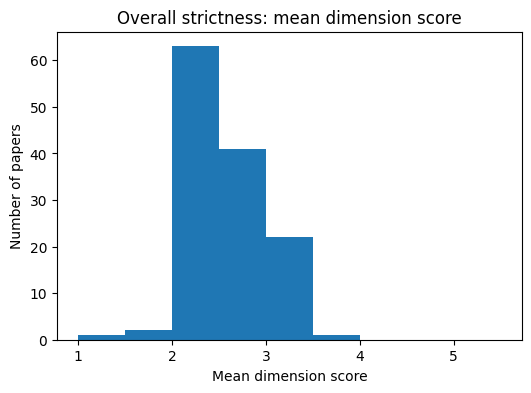

In [25]:
plt.figure(figsize=(6, 4))
plt.hist(df_reviews["mean_dimension_score"], bins=np.arange(1, 5.6, 0.5))
plt.xlabel("Mean dimension score")
plt.ylabel("Number of papers")
plt.title("Overall strictness: mean dimension score")
plt.show()


## 13. Evidence and explanation length diagnostics

This is useful because very short evidence or explanation fields can indicate generic or shallow reviewing.

In [26]:
df_criteria["evidence_len"] = df_criteria["evidence"].fillna("").str.len()
df_criteria["explanation_len"] = df_criteria["explanation"].fillna("").str.len()

df_criteria[["evidence_len", "explanation_len"]].describe()


,evidence_len,explanation_len
count,2470.000000,2470.000000
mean,198.500405,202.697976
std,68.299360,73.362614
min,11.000000,49.000000
25%,150.000000,152.000000
50%,188.000000,193.000000
75%,236.750000,248.000000
max,571.000000,709.000000


In [27]:
short_evidence = df_criteria.sort_values("evidence_len").head(20)[[
    "paper_id", "criterion_name", "verdict", "criterion_score", "evidence", "explanation"
]]
short_evidence


,paper_id,criterion_name,verdict,criterion_score,evidence,explanation
1156,idea_013_01,unsupported_claims,not_satisfied,0.0,None found.,"All major claims (e.g., CA outperforms others) are backed by the provided numerical results and ablation studies."
1359,idea_015_02,baselines_clearly_named,partially_satisfied,0.5,"Baselines include SimCLR, MoCo, FixMatch, MixMatch.","Baselines are named but lack specific versioning or implementation details (e.g., hyperparameters for MoCo)."
435,idea_005_03,no_comparison_to_prior_work,not_satisfied,0.0,We compare our approach against three baseline families...,"The paper explicitly includes a Related Work section and a Baselines section in the Experiments, comparing against supervised, unsupervised, and semi-superv..."
712,idea_008_03,datasets_and_setup_specified,partially_satisfied,0.5,"The paper mentions 'NASDAQ, S&P 500' and 'NOAA... MERRA-2'.","Dataset names are provided, but crucial setup details are missing: normalization methods, handling of missing values, train/validation/test splits (specific..."
542,idea_006_04,baselines_clearly_named,partially_satisfied,0.5,"Baselines mentioned: FixMatch, MixMatch, SimCLR, MoCo, BYOL.","The baselines are named, but the specific configuration (e.g., MoCo v1 vs v2, FixMatch hyperparameters) is not provided, making fair comparison difficult."
143,idea_002_03,baselines_clearly_named,partially_satisfied,0.5,"Baselines include 'triplet loss', 'DeepMetric', 'kernel PCA'.","Baselines are named but their specific implementations or versions (e.g., which DeepMetric variant) are not specified."
682,idea_008_01,no_comparison_to_prior_work,partially_satisfied,0.5,"The Related Work section reviews SOM-VAE, E3D-LSTM, and others...","While prior work is discussed, the comparison is not rigorous or quantitative, so the penalty for lack of comparison is applied but mitigated slightly by th..."
1264,idea_014_02,baselines_clearly_named,satisfied,1.0,"Baselines are explicitly named: 'FixMatch, MixMatch', 'DANN, MMD'.",Standard baselines are clearly named and appropriate for the task.
1341,idea_015_01,evaluation_metrics_defined,partially_satisfied,0.5,"Metrics: 'accuracy on older tasks', 'forgetting rate', 'F1 scores'.","Metrics are named, but the exact formulas (e.g., how 'forgetting rate' is calculated) or specific definitions (e.g., specific F1 macro/micro) are not provided."
1355,idea_015_02,contribution_clearly_identified,partially_satisfied,0.5,The contribution is identified as a comparative evaluation framework.,The contribution is stated but its novelty is unclear without comparison to existing comprehensive benchmarks.


## 15. Suggested thesis observations

After running the notebook, look for these patterns:

1. Which dimension receives the lowest scores? This often reveals the main weakness of generated papers.
2. Which criteria are most often partially satisfied? These are usually where LLM-generated papers sound plausible but lack detail.
3. Which penalties activate most often? These identify common failure modes.
4. Is confidence aligned with low scores? If not, use the consistency metric later.
5. Are scores clustered around 3? This can indicate reviewer conservatism or rubric calibration issues.
